In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Constants

In [2]:
str_dirname_output = './output'
str_variant = 'noPTImodel10'

## Make output directory

In [3]:
try:
    os.mkdir(str_dirname_output)
except FileExistsError:
    pass

## Variant directory

In [4]:
try:
    os.mkdir(f'{str_dirname_output}/{str_variant}')
except FileExistsError:
    pass

## Single debtor

In [5]:
df_single = pd.read_csv(f'../01_single/output/{str_variant}/df_times.csv')
df_single['Type'] = 'Single'
# get the total time
flt_sec_single = df_single['sec'].sum()
df_single

,step,sec,prop,Type
0,Get Data,0.544811,0.113376,Single
1,Preprocessing,0.540325,0.112443,Single
2,Predictions,0.036857,0.007670,Single
3,Adverse Action,0.185684,0.038641,Single
4,Counter Offers,3.488526,0.725969,Single
5,Generate Output,0.009134,0.001901,Single


,step,sec,prop,Type
0,Get Data,0.544811,0.113376,Single
1,Preprocessing,0.540325,0.112443,Single
2,Predictions,0.036857,0.007670,Single
3,Adverse Action,0.185684,0.038641,Single
4,Counter Offers,3.488526,0.725969,Single
5,Generate Output,0.009134,0.001901,Single


## Codebtor

In [6]:
df_codebtor = pd.read_csv(f'../02_codebtor/output/{str_variant}/df_times.csv')
df_codebtor['Type'] = 'Codebtor'
# get total time
flt_sec_codebtor = df_codebtor['sec'].sum()
df_codebtor

,step,sec,prop,Type
0,Get Data,0.173231,0.095268,Codebtor
1,Preprocessing,0.522142,0.287153,Codebtor
2,Predictions,0.029402,0.016170,Codebtor
3,Adverse Action,0.170279,0.093645,Codebtor
4,Counter Offers,0.914229,0.502782,Codebtor
5,Generate Output,0.009057,0.004981,Codebtor


,step,sec,prop,Type
0,Get Data,0.173231,0.095268,Codebtor
1,Preprocessing,0.522142,0.287153,Codebtor
2,Predictions,0.029402,0.016170,Codebtor
3,Adverse Action,0.170279,0.093645,Codebtor
4,Counter Offers,0.914229,0.502782,Codebtor
5,Generate Output,0.009057,0.004981,Codebtor


## Concatenate

In [7]:
df_all = pd.concat([df_single, df_codebtor])
# save
str_filename = 'df_all.csv'
str_local_path = f'{str_dirname_output}/{str_variant}/{str_filename}'
df_all.to_csv(str_local_path, index=False)
# show
df_all

,step,sec,prop,Type
0,Get Data,0.544811,0.113376,Single
1,Preprocessing,0.540325,0.112443,Single
2,Predictions,0.036857,0.007670,Single
3,Adverse Action,0.185684,0.038641,Single
4,Counter Offers,3.488526,0.725969,Single
5,Generate Output,0.009134,0.001901,Single
0,Get Data,0.173231,0.095268,Codebtor
1,Preprocessing,0.522142,0.287153,Codebtor
2,Predictions,0.029402,0.016170,Codebtor
3,Adverse Action,0.170279,0.093645,Codebtor


,step,sec,prop,Type
0,Get Data,0.544811,0.113376,Single
1,Preprocessing,0.540325,0.112443,Single
2,Predictions,0.036857,0.007670,Single
3,Adverse Action,0.185684,0.038641,Single
4,Counter Offers,3.488526,0.725969,Single
5,Generate Output,0.009134,0.001901,Single
0,Get Data,0.173231,0.095268,Codebtor
1,Preprocessing,0.522142,0.287153,Codebtor
2,Predictions,0.029402,0.016170,Codebtor
3,Adverse Action,0.170279,0.093645,Codebtor


## Plot

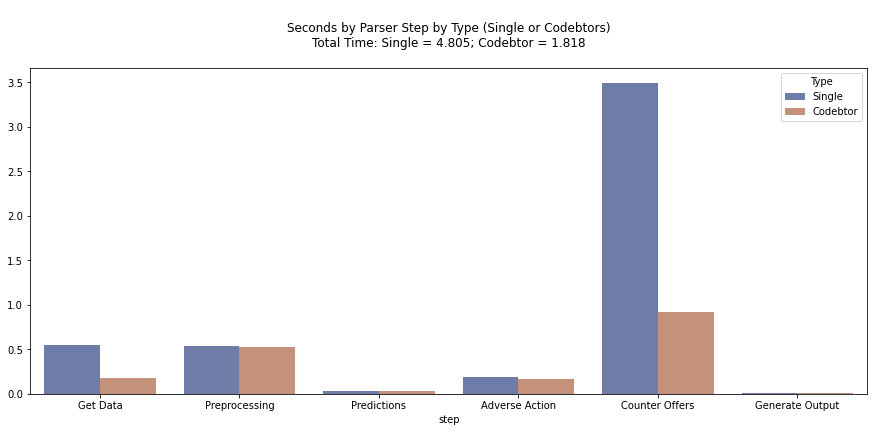

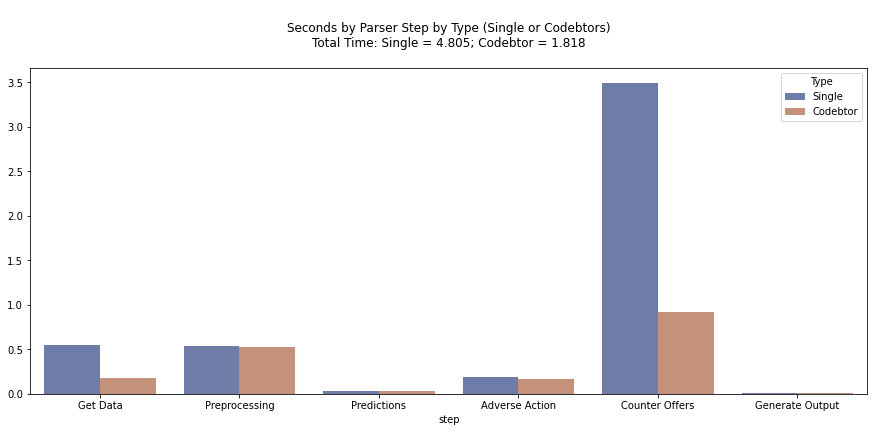

In [8]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.barplot(
    data=df_all, 
    x='step', 
    y='sec', 
    hue='Type',
    palette='dark', 
    alpha=.6, 
    ax=ax,
)
str_title = f"""
Seconds by Parser Step by Type (Single or Codebtors)
Total Time: Single = {flt_sec_single:0.3f}; Codebtor = {flt_sec_codebtor:0.3f}
"""
ax.set_title(str_title)
ax.set_ylabel('Time (sec.)')
ax.set_ylabel('')
plt.savefig(f'{str_dirname_output}/{str_variant}/plt_times.png', bbox_inches='tight')
plt.show()

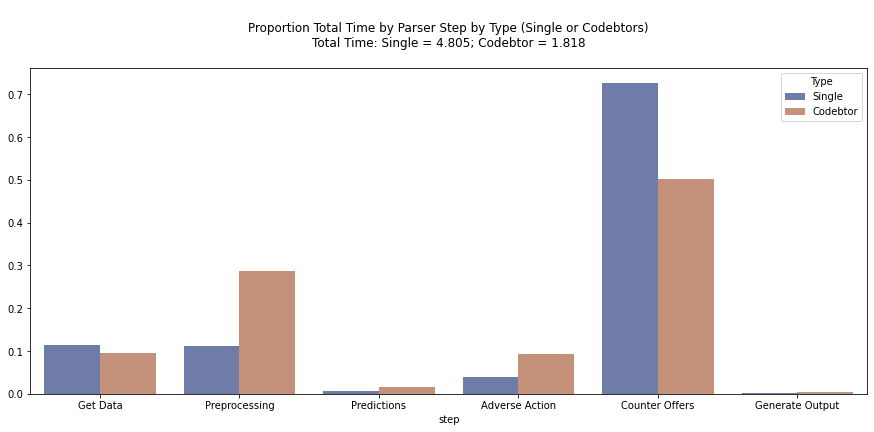

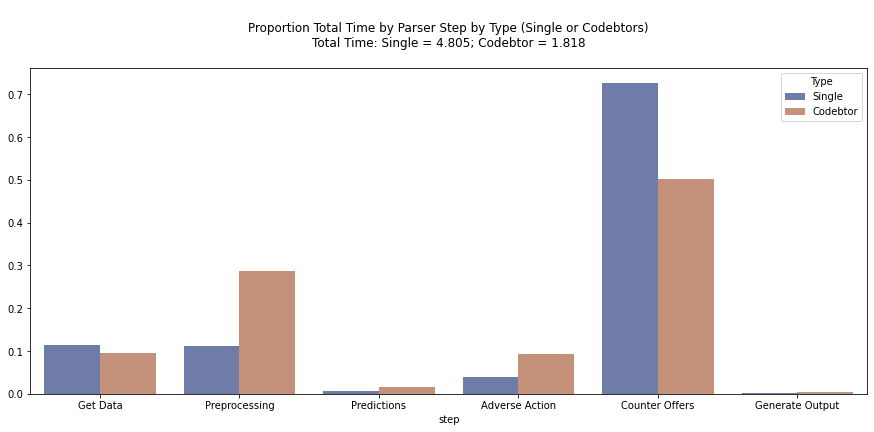

In [9]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.barplot(
    data=df_all, 
    x='step', 
    y='prop', 
    hue='Type',
    palette='dark', 
    alpha=.6, 
    ax=ax,
)
str_title = f"""
Proportion Total Time by Parser Step by Type (Single or Codebtors)
Total Time: Single = {flt_sec_single:0.3f}; Codebtor = {flt_sec_codebtor:0.3f}
"""
ax.set_title(str_title)
ax.set_ylabel('Proportion')
ax.set_ylabel('')
plt.savefig(f'{str_dirname_output}/{str_variant}/plt_proportions.png', bbox_inches='tight')
plt.show()